In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)
print("Libraries imported successfully.")

Libraries imported successfully.


In [44]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
print("Dataset Shape:", X.shape)
print("Target Shape :", y.shape)

Dataset Shape: (178, 13)
Target Shape : (178,)


In [ ]:
wine["data"].isnull().sum()
d

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

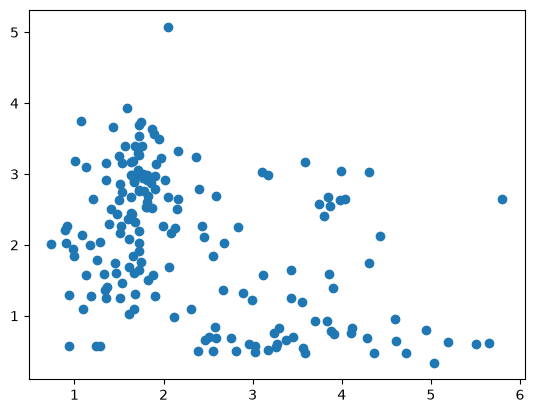

In [46]:
plt.scatter(wine["data"]["malic_acid"],wine["data"]["flavanoids"])

In [47]:
for i in wine["data"].columns:
    print(i)
for class_id,class_name in enumerate(wine.target_names):
    print(class_id,"--",class_name)

alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline
0 -- class_0
1 -- class_1
2 -- class_2


In [48]:
df=wine.frame
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [50]:
class_counts=y.value_counts().sort_index()
class_counts#it is a kind of dataframe which has the key as the classes and the values as the no of values 

target
0    59
1    71
2    48
Name: count, dtype: int64

<BarContainer object of 3 artists>

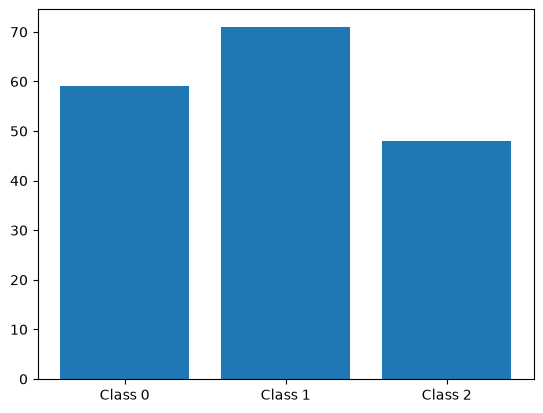

In [51]:
plt.bar(
['Class 0', 'Class 1', 'Class 2'],
class_counts.values
)

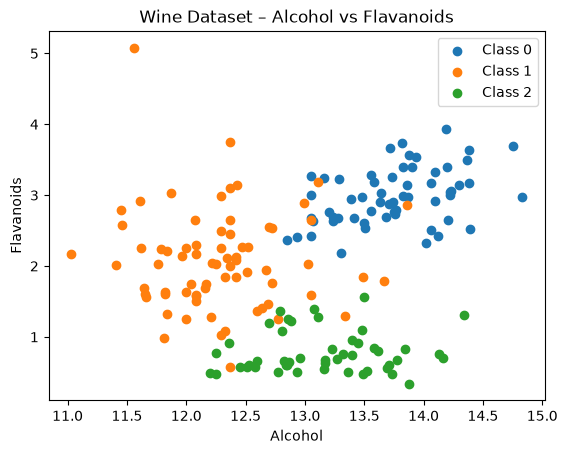

In [52]:
for target_value in class_counts.index:
    subset=X[y==target_value]
    plt.scatter(
        subset["alcohol"],
        subset["flavanoids"],
        label=f"Class {target_value}"
    )
plt.xlabel("Alcohol")
plt.ylabel("Flavanoids")
plt.title("Wine Dataset – Alcohol vs Flavanoids")
plt.legend()

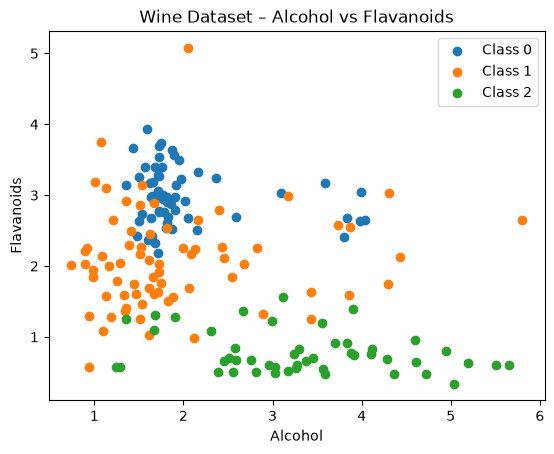

In [53]:
for target_value in class_counts.index:
    subset=X[y==target_value]
    plt.scatter(
        subset["malic_acid"],
        subset["flavanoids"],
        label=f"Class {target_value}"
    )
plt.xlabel("Alcohol")
plt.ylabel("Flavanoids")
plt.title("Wine Dataset – Alcohol vs Flavanoids")
plt.legend()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'alcohol'),
  Text(1, 0, 'malic_acid'),
  Text(2, 0, 'ash'),
  Text(3, 0, 'alcalinity_of_ash'),
  Text(4, 0, 'magnesium'),
  Text(5, 0, 'total_phenols'),
  Text(6, 0, 'flavanoids'),
  Text(7, 0, 'nonflavanoid_phenols'),
  Text(8, 0, 'proanthocyanins'),
  Text(9, 0, 'color_intensity'),
  Text(10, 0, 'hue'),
  Text(11, 0, 'od280/od315_of_diluted_wines'),
  Text(12, 0, 'proline')])

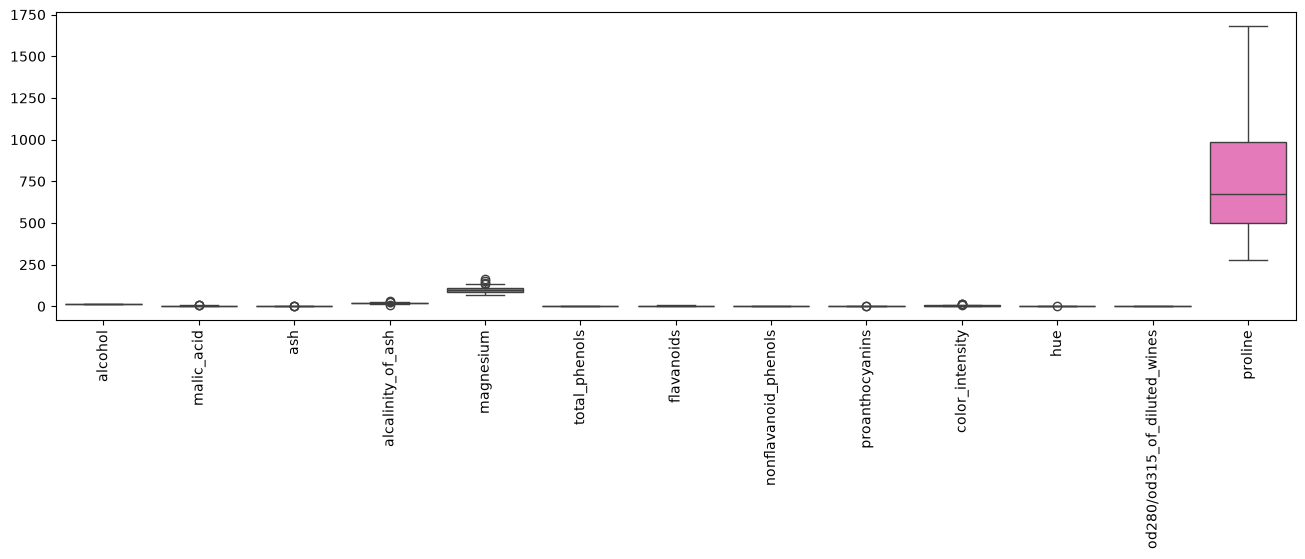

In [60]:
plt.figure(figsize=(16,4))
sns.boxplot(X)
plt.xticks(rotation=90)

In [62]:
X=wine.data
y=wine.target
print("Number of observations:", X.shape[0])
print("Number of features :", X.shape[1])

Number of observations: 178
Number of features : 13


In [68]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    y,
    random_state=42,
    stratify=y
    )
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)
print(Y_test.value_counts().sort_index())
print(Y_train.value_counts().sort_index())

Training data: (133, 13)
Testing data : (45, 13)
target
0    15
1    18
2    12
Name: count, dtype: int64
target
0    44
1    53
2    36
Name: count, dtype: int64


In [69]:
dt_model=DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
dt_model.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [92]:
Y_pred=dt_model.predict(X_test)
Y_pred
pd.DataFrame({"Traing":Y_test,"predicted":Y_pred}).sort_index()

,Traing,predicted
7,0,0
10,0,0
14,0,0
18,0,0
20,0,0
22,0,0
23,0,0
28,0,0
35,0,0
38,0,1


In [94]:
accuracy_dt=accuracy_score(
    Y_test,
    Y_pred
)
precision_dt=precision_score(
    Y_test,
    Y_pred,
    average="weighted"
)
recall_dt=recall_score(
    Y_test,
    Y_pred,
    average="weighted"
)
f1_dt=f1_score(
    Y_test,
    Y_pred,
    average="weighted"
)
print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Performance
-------------------------
Accuracy : 0.9555555555555556
Precision: 0.9600000000000001
Recall : 0.9555555555555556
F1 Score : 0.9558589126489386


In [96]:
print(
    classification_report(
        Y_test,
        Y_pred,
        target_names=wine.target_names
    )
)

              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45

